## Numbers Dataset

We have a dataset of handwritten digits from 0 to 9

We need some library to read the images, I've chosen the pillow library which comes with Anaconda, if you need to 

pip install Pillow

should install it for you

In [9]:
import numpy as np
import glob
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

In [10]:
## Printing Examples
def printexamples(X, y, examples_per_class = 10, number_of_classes = 10, mult = 1.0):
    pos = 0
    data = pd.DataFrame(y, columns=["yvalue"])
    for cls in range(number_of_classes):
        this_class = data[data["yvalue"] == cls]
        idxs = this_class.sample(examples_per_class).index
        for i, idx in enumerate(idxs):
            plt.subplot(examples_per_class, number_of_classes, i * number_of_classes + cls + 1)
            plt.imshow((X[idx]*mult).reshape(20,20).astype('uint8'), cmap='gray')
            plt.axis('off')
            if i == 0:
                plt.title(str(cls))
    plt.show()

In [11]:
# Generate file list
filelist = glob.glob('data/*/*.png') 

# Load images and labels
X = []
y = []

# for fname in filelist:
#     # Load image and convert to array
#     img = np.array(Image.open(fname))
#     # Flatten 20x20
#     X.append(img.flatten())
    
X = np.array([np.array(Image.open(fname)).flatten() for fname in filelist])   
y = (np.array([int(fname.split('/')[-2]) for fname in filelist]))

In [12]:
y

array([3, 3, 3, ..., 7, 7, 7], shape=(5000,))

In [13]:
print("x shape:", X.shape)
print("y shape:", y.shape)

x shape: (5000, 400)
y shape: (5000,)


### What range of values do the pixels take?
The pixels should range from 0 to 255.

In [14]:
# Scale the data so pixel values lie in [0, 1]
X = X / 255.0

In [15]:
print("x shape:", X.shape)
print("y shape:", y.shape)

x shape: (5000, 400)
y shape: (5000,)


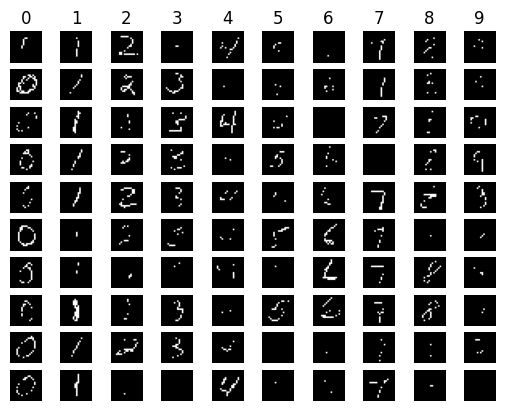

In [16]:
printexamples(X, y)

In [17]:
# Split dataset
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, random_state=1138, stratify=y, test_size=0.2)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, random_state=1138, stratify=y_temp, test_size=0.25)

In [18]:
X_train.shape

(3000, 400)

## Linear Support Vector Machine

In [19]:
from sklearn.svm import SVC
model_svc = SVC(kernel='linear')

model_svc.fit(X_train, y_train)

# Validation accuracy
print(model_svc.score(X_valid, y_valid))

# Training accuracy
print(model_svc.score(X_train, y_train))

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model_svc.predict(X_valid)
print(confusion_matrix(y_valid, y_pred))

# Classification report
print(classification_report(y_valid, y_pred))

# Use 5-fold cross validation on the training set to tune the regularisation parameter C
from sklearn.model_selection import GridSearchCV
model_svc = SVC(kernel='linear') # re-initialise model
param_grid = {'C' : [0.001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]}
grid_model_svc = GridSearchCV(SVC(kernel='linear'), param_grid)
grid_model_svc.fit(X_train, y_train)

# Select the best C based on cross-validation performance
print("Best C:", grid_model_svc.best_params_)

# Retrain using the best C on the training set. Report the validation accuracy


0.904
0.998
[[98  0  0  0  0  2  0  0  0  0]
 [ 0 98  0  0  1  0  0  0  1  0]
 [ 1  1 88  0  4  0  2  1  3  0]
 [ 0  1  1 88  0  6  0  1  1  2]
 [ 0  0  0  0 98  0  1  0  0  1]
 [ 0  0  0  9  0 90  0  0  0  1]
 [ 1  0  2  0  2  3 91  0  1  0]
 [ 2  4  1  0  4  0  0 84  1  4]
 [ 0  1  1  2  1 11  0  0 83  1]
 [ 1  0  1  0  8  1  0  2  1 86]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       100
           1       0.93      0.98      0.96       100
           2       0.94      0.88      0.91       100
           3       0.89      0.88      0.88       100
           4       0.83      0.98      0.90       100
           5       0.80      0.90      0.85       100
           6       0.97      0.91      0.94       100
           7       0.95      0.84      0.89       100
           8       0.91      0.83      0.87       100
           9       0.91      0.86      0.88       100

    accuracy                           0.90      1000
   macr

### Which digits are most frequently confused?
**Answer**: 5 with precision 0.85

### Comment on whether overfitting appears to be present:
Validation score is 0.918 and training score is 0.996 which indicates overfitting since the model does not perform as well on data it hasn't seen yet.

## Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier()

random_forest.fit(X_train, y_train)

# Validation accuracy
print(random_forest.score(X_valid, y_valid))

# Training accuracy
print(random_forest.score(X_train, y_train))

# Confusion matrix
y_pred_rf = random_forest.predict(X_valid)
print(confusion_matrix(y_valid, y_pred_rf))

# Classification report
print(classification_report(y_valid, y_pred_rf))



0.932
1.0
[[98  0  0  0  0  0  1  0  1  0]
 [ 0 99  0  0  0  0  0  0  0  1]
 [ 2  0 92  1  1  0  1  0  3  0]
 [ 0  2  3 91  0  1  0  1  1  1]
 [ 0  0  2  0 96  0  1  0  0  1]
 [ 1  0  0  2  2 93  0  0  0  2]
 [ 1  0  1  0  1  3 93  1  0  0]
 [ 1  4  1  1  2  0  0 88  1  2]
 [ 0  1  0  2  0  4  1  0 92  0]
 [ 2  0  0  0  4  0  0  2  2 90]]
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       100
           1       0.93      0.99      0.96       100
           2       0.93      0.92      0.92       100
           3       0.94      0.91      0.92       100
           4       0.91      0.96      0.93       100
           5       0.92      0.93      0.93       100
           6       0.96      0.93      0.94       100
           7       0.96      0.88      0.92       100
           8       0.92      0.92      0.92       100
           9       0.93      0.90      0.91       100

    accuracy                           0.93      1000
   macro 